In [28]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

task 1.1 - calculation of the colinear lagrangian points

In [82]:
def potential_U(X, mu):
    r1 = ((X[0] + mu)**2 + X[1]**2 + X[2]**2)**0.5
    r2 = ((X[0] + mu - 1)**2 + X[1]**2 + X[2]**2)**0.5
    U = - (1 - mu) / r1 - mu / r2 - 0.5 * (X[0]**2 + X[1]**2)
    return U
def dU_dx(x, mu):
    term1 = (1 - mu) / abs(x + mu)**3 * (x + mu)
    term2 = mu / abs(x + mu - 1)**3 * (x + mu - 1)
    return x - term1 - term2
def d2U_dx2(x, mu):
    term1 = -2 * (1 - mu) / abs(x + mu)**3 
    term2 = -2 * mu / abs(x + mu - 1)**3 
    return 1 - term1 - term2
def d2r(x, mu):
    r1 = abs(x + mu)
    r2 = abs(x + mu - 1)
    d2r = -(( 1 - mu )/r1**3 * (x + mu) + mu/r2**3 * (x + mu - 1)) + x 
    return d2r
def Delta_U_vec(X, mu):
    r1 = ((X[0] + mu)**2 + X[1]**2 + X[2]**2)**0.5
    r2 = ((X[0] + mu - 1)**2 + X[1]**2 + X[2]**2)**0.5
    dUx = -X[0] + (1 - mu) * (X[0] + mu) / r1**3 + mu * (X[0] + mu - 1) / r2**3
    dUy = -X[1] + (1 - mu) * X[1] / r1**3 + mu * X[1] / r2**3
    dUz = X[2] * ((1 - mu)  / r1**3 + mu / r2**3)
    Delta_U = np.array([dUx, dUy, dUz])
    return Delta_U


mu_SM = 3.227154996101724e-7 # Sun-Mars mass ratio
tol = 1e-10
x = 1.01
err_rel = abs(dU_dx(x, mu_SM) / d2U_dx2(x, mu_SM))

# Newton's method
while err_rel > tol and abs(d2U_dx2(x, mu_SM)) > tol:
    x = x - dU_dx(x, mu_SM) / d2U_dx2(x, mu_SM)
    err_rel = abs(dU_dx(x, mu_SM) / d2U_dx2(x, mu_SM))
L2_SM = x
print(f'Sun - Mars L2: {x}')

# Verification
print(f'Verification S-M d2r/dt2: {d2r(x, mu_SM)}')

mass2 = 5.972e24 # Earth mass
mu_SE = 3.0542e-6 # Sun-Earth mass ratio
err_rel = abs(dU_dx(x, mu_SE) / d2U_dx2(x, mu_SE))

# Newton's method
while err_rel > tol and abs(d2U_dx2(x, mu_SE)) > tol:
    x = x - dU_dx(x, mu_SE) / d2U_dx2(x, mu_SE)
    err_rel = abs(dU_dx(x, mu_SE) / d2U_dx2(x, mu_SE))
L2_SE = x
print(f'Sun - Earth L2: {x}')
print(f'Verification S-E d2r/dt2: {d2r(x, mu_SE)}')

# extra calculation for L1
x = 0.99
err_rel = abs(dU_dx(x, mu_SE) / d2U_dx2(x, mu_SE))

# Newton's method
while err_rel > tol and abs(d2U_dx2(x, mu_SE)) > tol:
    x = x - dU_dx(x, mu_SE) / d2U_dx2(x, mu_SE)
    err_rel = abs(dU_dx(x, mu_SE) / d2U_dx2(x, mu_SE))
L1_SE = x
print(f'Sun - Earth L1: {x}')


Sun - Mars L2: 1.0047631067375549
Verification S-M d2r/dt2: -1.5687451337953462e-11
Sun - Earth L2: 1.0100904357842546
Verification S-E d2r/dt2: -1.3322676295501878e-15
Sun - Earth L1: 0.9899709220588538


task 2.1 - calculation of artificial equilibrium points

Beta at S-E L2: 0.022906137283393635
Beta at S-M L2: 0.034180052134122355


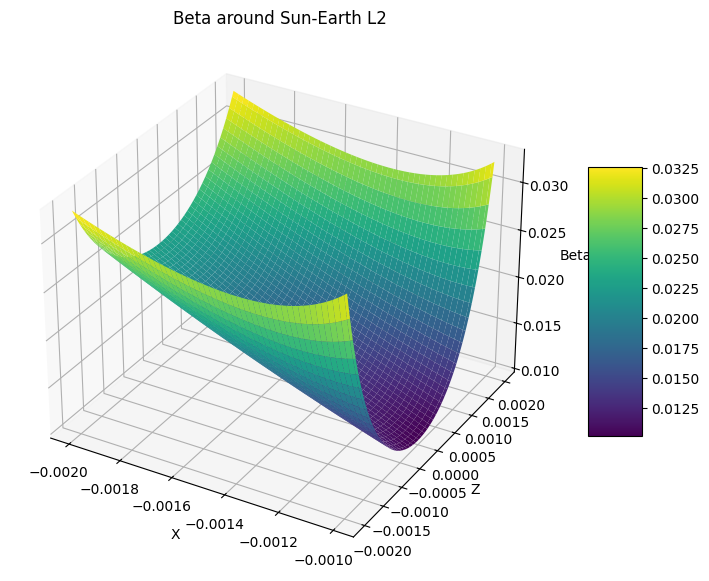

Optimal orientation SE (task 2.1b): [1. 0. 0.]
Optimal orientation SM (task 2.1b): [1. 0. 0.]


C:\Users\tomma\AppData\Local\Temp\ipykernel_11740\3973020120.py:70: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  a_centripetal = - np.cross(ang_velocity, np.cross(ang_velocity, X[0:2]))
C:\Users\tomma\AppData\Local\Temp\ipykernel_11740\3973020120.py:71: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  a_coriolis = -2 * np.cross(ang_velocity, X[3:5])
C:\Users\tomma\AppData\Local\Temp\ipykernel_11740\3973020120.py:96: RuntimeWarning: invalid value encountered in divide
  v = vec / np.linalg.norm(vec) * current_scale


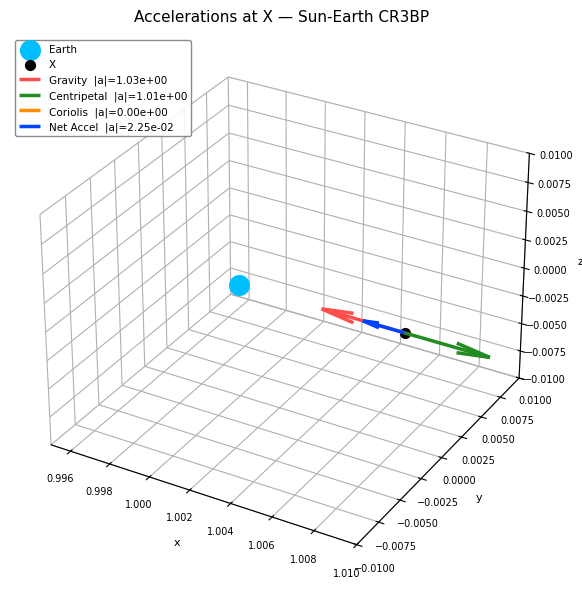

Net acceleration at S-E L2 with solar sail: [2.77555756e-17 0.00000000e+00 0.00000000e+00] m/s^2
Net acceleration at S-M L2 with solar sail: [5.55111512e-17 0.00000000e+00 0.00000000e+00] m/s^2
Norm of total acceleration at shifted S-E L2: 2.78e-17 m/s^2 
Norm of total acceleration at shifted S-M L2: 5.55e-17 m/s^2 
Beta at verification point 1: 0.0363 (paper value: 0.0363)
Beta at verification point 2: 0.0363 (paper value: 0.0363)


In [98]:
def Beta(X, mu, n = None, n_rf_r1 = None):
    """ Lightness parameter for the solar sail"""
    r1 = ((X[0] + mu)**2 + X[1]**2 + X[2]**2)**0.5
    R1 = np.array([X[0] + mu, X[1], X[2]]) / r1
    Delta_U = Delta_U_vec(X, mu)
    if n is None and n_rf_r1 is None:
        n = Delta_U / np.linalg.norm(Delta_U)
    elif n_rf_r1 is not None:
        # Rotational matrix R (DCM)
        gamma = np.arctan2(X[1], X[0] + mu) # angle between the position vector and the x-axis
        i = np.arctan2(X[2], np.sqrt((X[0] + mu)**2 + X[1]**2)) # angle between the position vector and the xy-plane
        R = np.array([[np.cos(i)*np.cos(gamma), np.sin(gamma)*np.cos(i), np.sin(i)],
                  [-np.sin(gamma), np.cos(gamma), 0],
                  [-np.cos(gamma)*np.sin(i), -np.sin(gamma)*np.sin(i), np.cos(i)]])
        n = R @ n_rf_r1
    Beta = r1**2 / (1 - mu) * Delta_U @ n / (R1 @ n)**2
    return Beta



L_shift = 0.00200
X_SE = np.array ([L2_SE - L_shift, 0, 0])
print(f'Beta at S-E L2: {Beta(X_SE, mu_SE)}')   

X_SM = np.array ([L2_SM - L_shift, 0, 0])
print(f'Beta at S-M L2: {Beta(X_SM, mu_SM)}')

z_shift = np.linspace(-0.002, 0.002, 100)
x_shift = np.linspace(-0.002, -0.001, 100)
Beta_matrix = np.zeros((len(z_shift), len(x_shift)))
Z_shift, X_shift = np.meshgrid(z_shift, x_shift)
for i in range(X_shift.shape[0]):
    for j in range(X_shift.shape[1]):
        X = np.array ([L2_SE + X_shift[i, j], 0, Z_shift[i, j]])
        Beta_matrix[i, j] = Beta(X, mu_SE)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X_shift, Z_shift, Beta_matrix, cmap='viridis')

# Aggiunta di dettagli
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
ax.set_title("Beta around Sun-Earth L2")
ax.set_xlabel("X")
ax.set_ylabel("Z")
ax.set_zlabel("Beta")

plt.show()

# orientation (task 2.1b)

Delta_U_SE = Delta_U_vec(X_SE, mu_SE)
n_SE = Delta_U_SE / np.linalg.norm(Delta_U_SE)
print(f'Optimal orientation SE (task 2.1b): {n_SE}')

Delta_U_SM = Delta_U_vec(X_SM, mu_SM)
n_SM = Delta_U_SM / np.linalg.norm(Delta_U_SM)
print(f'Optimal orientation SM (task 2.1b): {n_SM}')

# ACCELERATIONS VISUAL REPRESENTATION 
def acceleration_vector(X, mu):
    X = np.array(list(X) + [0,0,0] if len(X)==3 else list(X), dtype=float)
    r1 = ((X[0] + mu)**2 + X[1]**2 + X[2]**2)**0.5
    R1 = [X[0] + mu, X[1], X[2]]/r1
    r2 = ((X[0] + mu - 1)**2 + X[1]**2 + X[2]**2)**0.5
    R2 = [X[0] + mu - 1, X[1], X[2]]/r2
    a_gravity = - (1 - mu) * R1 / r1**2 - mu * R2 / r2**2
    ang_velocity = np.array([0, 0, 1]) # otherwise it would not be CR3BP
    a_centripetal = - np.cross(ang_velocity, np.cross(ang_velocity, X[0:2]))
    a_coriolis = -2 * np.cross(ang_velocity, X[3:5])
    return a_gravity, a_centripetal, a_coriolis
 
a_gravity_SE, a_centripetal_SE, a_coriolis_SE = acceleration_vector(X_SE, mu_SE)
a_gravity_SM, a_centripetal_SM, a_coriolis_SM = acceleration_vector(X_SM, mu_SM)

### For visualization, I will focus on the Sun-Earth L2 point
ag_SE, ac_SE, acor_SE = acceleration_vector(X_SE, mu_SE)

fig = plt.figure(figsize=(15, 6), facecolor='white')
ax = fig.add_subplot(111, projection='3d', facecolor="white")

earth_pos = np.array([1-mu_SE, 0, 0])
X_pos     = np.array(X_SE[:3])

ax.scatter(*earth_pos, s=200, color='deepskyblue', zorder=5, label='Earth')
ax.scatter(*X_pos,     s=50,  color='black',       zorder=5, label='X')

scale = 0.004
for label, vec, color in [('Gravity',     ag_SE,   '#ff4d4d'),
                          ('Centripetal', ac_SE,   'forestgreen'), # Scurito per sfondo bianco
                          ('Coriolis',    acor_SE, 'darkorange'),  # Scurito per sfondo bianco
                          ('Net Accel',   ag_SE+ac_SE+acor_SE, "#0044ff")]:
    current_scale = scale * 0.5 if label == 'Net Accel' else scale
    
    v = vec / np.linalg.norm(vec) * current_scale
    ax.quiver(*X_pos, *v, color=color, linewidth=2.5, arrow_length_ratio=0.4,
              label=f'{label}  |a|={np.linalg.norm(vec):.2e}')

for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
    pane.fill = False
ax.tick_params(colors='black', labelsize=7)
ax.set_xlabel('x', color='black', fontsize=8)
ax.set_ylabel('y',           color='black', fontsize=8)
ax.set_zlabel('z',           color='black', fontsize=8)
ax.set_title('Accelerations at X — Sun-Earth CR3BP', color='black', fontsize=11, pad=10)
ax.legend(loc='upper left', fontsize=7.5, facecolor='white', labelcolor='black', framealpha=0.9, edgecolor='gray')
ax.set_xlim([0.995, 1.01]); ax.set_ylim([-0.01, 0.01]); ax.set_zlim([-0.01, 0.01])

plt.tight_layout()
plt.savefig('accel_3d.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()


# Verification of the net acceleration at L2
# computation of total acceleration on the shifted point, including the solar sail effect
def net_accel(X, mu, n_rf_r1, Beta):
    """"ATTENTION, n must be in r1, theta, nu reference frame, 
    otherwise the solar sail acceleration will not be correctly computed"""
    ag, ac, acor = acceleration_vector(X, mu)
    r1 = ((X[0] + mu)**2 + X[1]**2 + X[2]**2)**0.5
    r1_hat = np.array([X[0] + mu, X[1], X[2]]) / r1
    # Rotational matrix R (DCM)
    gamma = np.arctan2(X[1], X[0] + mu) # angle between the position vector and the x-axis
    i = np.arctan2(X[2], np.sqrt((X[0] + mu)**2 + X[1]**2)) # angle between the position vector and the xy-plane
    R = np.array([[np.cos(i)*np.cos(gamma), np.sin(gamma)*np.cos(i), np.sin(i)],
                  [-np.sin(gamma), np.cos(gamma), 0],
                  [-np.cos(gamma)*np.sin(i), -np.sin(gamma)*np.sin(i), np.cos(i)]])
    n = R @ n_rf_r1
    a_solar_sail = Beta * (1 - mu) / r1**2 * ( r1_hat @ n )**2 * n
    return ag + ac + acor + a_solar_sail


n_rf_r1 = np.array([1, 0, 0]) # optimal orientation is along r1
Beta_SE = Beta(X_SE, mu_SE)
net_acceleration_SE = net_accel(X_SE, mu_SE, n_rf_r1, Beta_SE)
print(f'Net acceleration at S-E L2 with solar sail: {net_acceleration_SE} m/s^2')
Beta_SM = Beta(X_SM, mu_SM)
net_acceleration_SM = net_accel(X_SM, mu_SM, n_rf_r1, Beta_SM)
print(f'Net acceleration at S-M L2 with solar sail: {net_acceleration_SM} m/s^2')

# Verification thanks to "Sunjammer: Preliminary End-to-End Mission Desig" paper

def verify_tot_acceleration(X_shifted, mu, beta, n_hat):
    """
    Verify that the sum of accelerations at the artificial equilibrium point is ~0.
    Uses equations (14) and (15) from Heiligers et al. (2014).
    """
    r1_vec = np.array([X_shifted[0] + mu, X_shifted[1], X_shifted[2]])
    r1_norm = np.linalg.norm(r1_vec)
    r1_hat = r1_vec / r1_norm
    r2_vec = np.array([X_shifted[0] + mu - 1, X_shifted[1], X_shifted[2]])
    r2_norm = np.linalg.norm(r2_vec)
    # 2. gravitational acceleration (Eq. 14, first two terms)
    ag_sun = -(1 - mu) * r1_vec / (r1_norm**3)
    ag_planet = -mu * r2_vec / (r2_norm**3)
    a_grav = ag_sun + ag_planet
    # 3. centrifugal acceleration (in the CR3BP omega = 1, and acts only in the xy-plane)
    a_centrifuga = np.array([X_shifted[0], X_shifted[1], 0])
    # 4. solar sail acceleration (Eq. 15)
    a_sail = beta * ((1 - mu) / r1_norm**2) * (np.dot(r1_hat, n_hat)**2) * n_hat

    a_tot = a_grav + a_centrifuga + a_sail
    a_norm = np.linalg.norm(a_tot)
    return a_norm

a_tot_SE = verify_tot_acceleration(X_SE, mu_SE, Beta_SE, n_SE)
print(f'Norm of total acceleration at shifted S-E L2: {a_tot_SE:.2e} m/s^2 ')
a_tot_SM = verify_tot_acceleration(X_SM, mu_SM, Beta_SM, n_SM)
print(f'Norm of total acceleration at shifted S-M L2: {a_tot_SM:.2e} m/s^2 ')

# Verification by benchmark
X_verif1 = np.array([0.983867, 0, 0]) # True sub-L1 
Beta_verif1 = Beta(X_verif1, mu_SE)
X_verif2 = np.array([0.983908, -0.00144, 0]) # Targeted sub-L1 AEP 
# THE PAPER REPORTED y = -0.0144, 
# but it should be -0.00144 since the spacecraft should stay in the 5 degree exclusion zone
Beta_verif2 = Beta(X_verif2, mu_SE)
print(f'Beta at verification point 1: {Beta_verif1:.4f} (paper value: 0.0363)')
print(f'Beta at verification point 2: {Beta_verif2:.4f} (paper value: 0.0363)')



Task 2.3/2.4 Solar Sail size

Length of the solar sail for Sun-Earth L2: 38.58 m
Length of the solar sail for Sun-Mars L2: 47.13 m


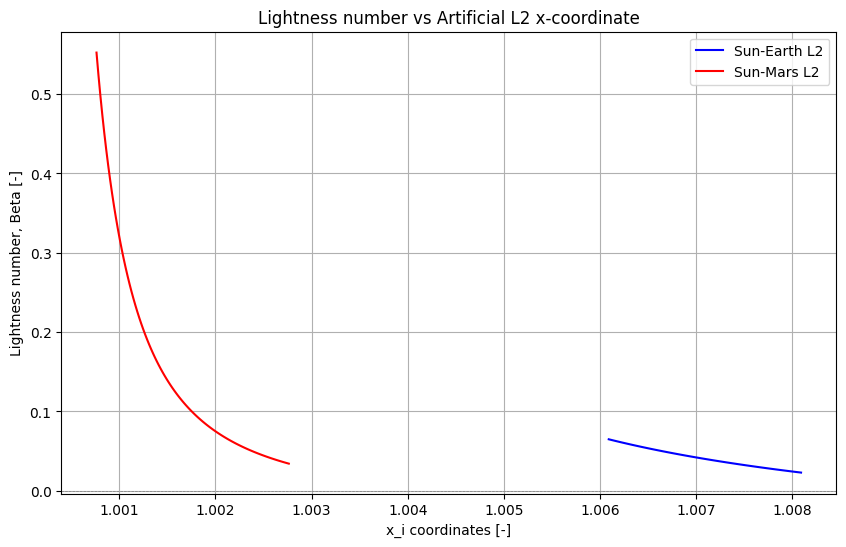

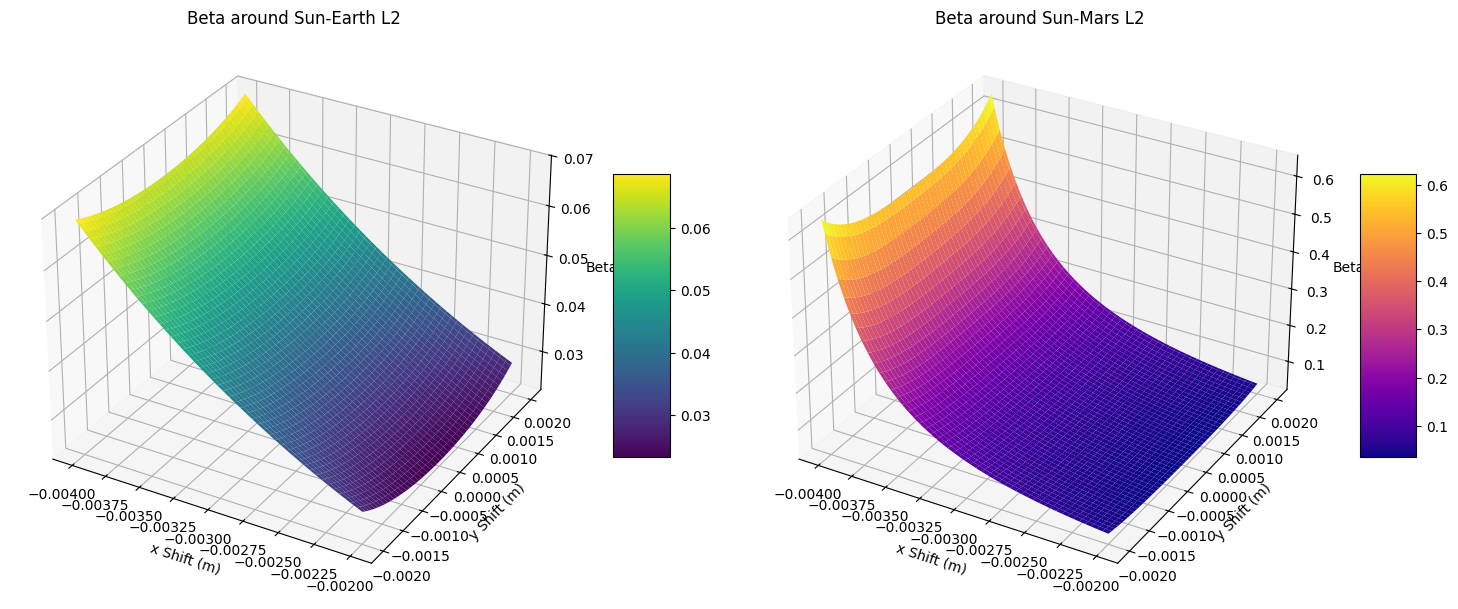

In [31]:
# starting from the forumlation for the acceleration with solar pressure (P) and the gravitational mu, 
# we can derive the lightness number (Beta) depending on the solar pressure constant at Eart 
# (P = W_E/c = 4.56e-6 N/m^2), the  Sun gravitational parameter (mu), 1 AU, and the area/mass ratio
#  of the sail. The formula is as follows:
# Beta = (2 * P_Earth * 1AU^2 * A/m / mu_S)
def lenght_sail( Beta, m):
    """ Calculate the area of the solar sail given the lightness number (Beta) and other parameters."""
    mu_S = 132712e15  # m^3/s^2
    P = 1368/299792458  # N/m^2
    AU = 149597870700  # m
    A = Beta * mu_S * m / (2 * P * AU**2)
    length = np.sqrt(A)    
    return length

m_spacecraft = 100 # kg
A_SE = lenght_sail(Beta(X_SE, mu_SE), m_spacecraft)
print(f'Length of the solar sail for Sun-Earth L2: {A_SE:.2f} m')
A_SM = lenght_sail(Beta(X_SM, mu_SM), m_spacecraft)
print(f'Length of the solar sail for Sun-Mars L2: {A_SM:.2f} m')

# Sensitivity analysis
x_shift = np.linspace(-0.002, -0.004, 100)
y_shift = np.linspace(-0.002, 0.002, 100)
Beta_vec_SE = np.array([Beta([L2_SE + x, 0, 0], mu_SE) for x in x_shift])
Beta_vec_SM = np.array([Beta([L2_SM + x, 0, 0], mu_SM) for x in x_shift])
plt.figure(figsize=(10, 6))
plt.plot(L2_SE + x_shift, Beta_vec_SE, label='Sun-Earth L2', color='blue')
plt.plot(L2_SM + x_shift, Beta_vec_SM, label='Sun-Mars L2', color='red')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.title('Lightness number vs Artificial L2 x-coordinate') 
plt.xlabel('x_i coordinates [-]')
plt.ylabel('Lightness number, Beta [-]')
plt.legend()
plt.grid()
plt.show()


X_shift, Y_shift = np.meshgrid(x_shift, y_shift)
Beta_matrix_SE = np.array([[Beta([L2_SE + x, y, 0], mu_SE) for x in x_shift] for y in y_shift])
Beta_matrix_SM = np.array([[Beta([L2_SM + x, y, 0], mu_SM) for x in x_shift] for y in y_shift])
fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')
surf1 = ax1.plot_surface(X_shift, Y_shift, Beta_matrix_SE, cmap='viridis')
surf2 = ax2.plot_surface(X_shift, Y_shift, Beta_matrix_SM, cmap='plasma')
ax1.set_title('Beta around Sun-Earth L2')
ax1.set_xlabel('x Shift (m)')
ax1.set_ylabel('y Shift (m)')
ax1.set_zlabel('Beta')
ax2.set_title('Beta around Sun-Mars L2')
ax2.set_xlabel('x Shift (m)')
ax2.set_ylabel('y Shift (m)')
ax2.set_zlabel('Beta')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=5)
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=5)
plt.tight_layout()
plt.show()





TASK 3.1 Stability of the (Artificial) Lagrange Points

Eigenvalues at Sun-Earth L2 (classical): ['-2.4843e+00+0.0000e+00j', '2.4843e+00+0.0000e+00j', '8.3267e-17+2.0570e+00j', '8.3267e-17-2.0570e+00j']
Eigenvalues at Sun-Earth L2 (artificial): ['-2.8902e+00+0.0000e+00j', '2.8902e+00+0.0000e+00j', '2.0817e-16+2.3104e+00j', '2.0817e-16-2.3104e+00j']
Eigenvalues at Sun-Mars L2 (classical): ['2.4969e+00+0.0000e+00j', '-2.4969e+00+0.0000e+00j', '0.0000e+00+2.0647e+00j', '0.0000e+00-2.0647e+00j']
Eigenvalues at Sun-Mars L2 (artificial): ['-3.5179e+00+0.0000e+00j', '3.5179e+00+0.0000e+00j', '-2.4980e-16+2.7121e+00j', '-2.4980e-16-2.7121e+00j']


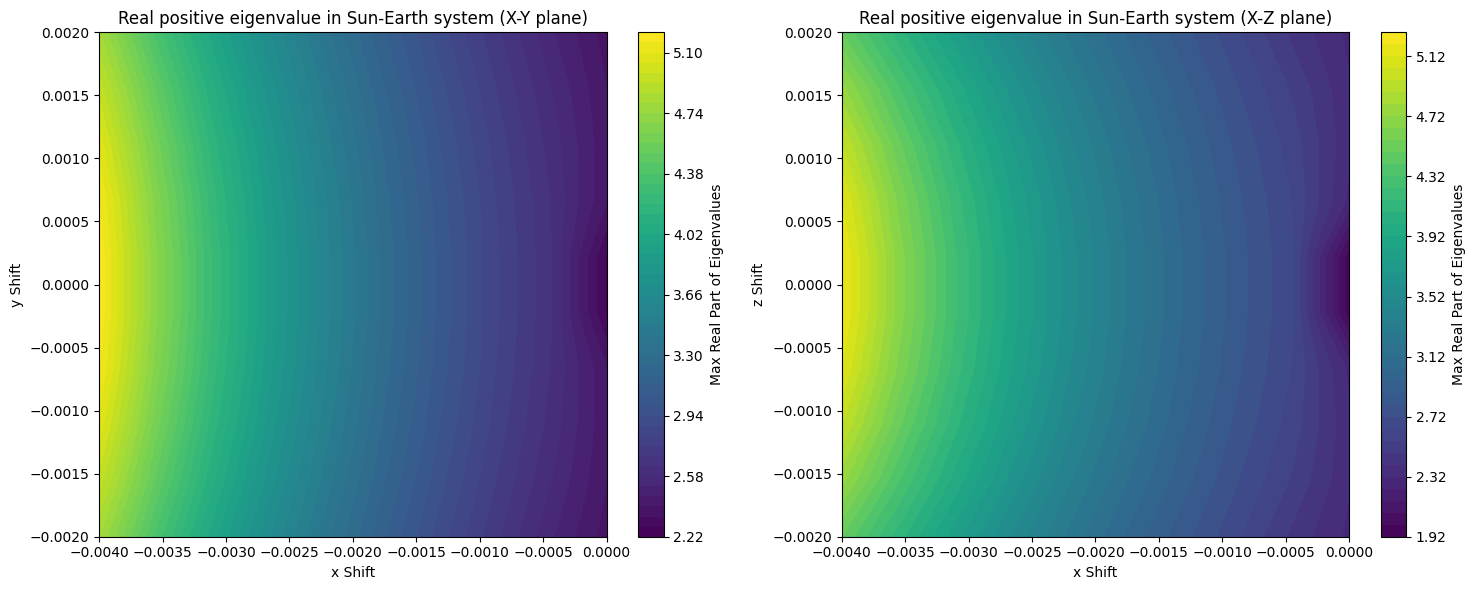

In [95]:
import sympy as sp
x, y, z, mu = sp.symbols('x y z mu')
r1_mod = sp.sqrt((x + mu)**2 + y**2 + z**2)
r1_vec = sp.Matrix([x + mu, y, z]) / r1_mod
r2_mod = sp.sqrt((x + mu - 1)**2 + y**2 + z**2)
r2_vec = sp.Matrix([x + mu - 1, y, z]) / r2_mod

r_mod = sp.sqrt(x**2 + y**2 + z**2)
r_vec = sp.Matrix([x, y, z]) / r_mod

# Gravitational Potential
U = (1 - mu) / r1_mod + mu / r2_mod + 0.5 * (x**2 + y**2)
dU_dx = sp.diff(U, x)
dU_dy = sp.diff(U, y)
d2U_dx2 = sp.diff(dU_dx, x)
d2U_dy2 = sp.diff(dU_dy, y)
d2U_dxdy = sp.diff(dU_dx, y)

# Solar Sail acceleration
beta = sp.symbols('beta') 
nx, ny, nz = sp.symbols('n_x n_y n_z')
n = sp.Matrix([nx, ny, nz]) # n must be expressed in x, y, z coord

a_s = beta * (1 - mu) / r_mod**2 * (r1_vec.dot(n))**2 * n
da_s_dx = sp.diff(a_s, x)
da_s_dy = sp.diff(a_s, y)

beta_SE = Beta([L2_SE - 0.001, 0, 0], mu_SE)
beta_SM = Beta([L2_SM - 0.001, 0, 0], mu_SM)

A = sp.Matrix([
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [d2U_dx2 + da_s_dx[0], d2U_dxdy + da_s_dy[0], 0, 2],
    [d2U_dxdy + da_s_dx[1], d2U_dy2 + da_s_dy[1], -2, 0],])

# eigenvalues of A for each system (classical and artificial)
A_SE_classical = A.subs({beta: 0, x: L2_SE, y: 0, z: 0, mu : mu_SE})
A_SE_classical = np.array(A_SE_classical).astype(np.float64)
eigenvals_SE_classical = np.linalg.eigvals(A_SE_classical)

A_SE_artificial = A.subs({beta: beta_SE, nx: r1_vec[0], ny: r1_vec[1], nz: r1_vec[2]})
A_SE_artificial = A_SE_artificial.subs({x: L2_SE - 0.001, y: 0, z: 0, mu: mu_SE}) # optimal orientation along r1
A_SE_artificial = np.array(A_SE_artificial).astype(np.float64)
eigenvals_SE_artificial = np.linalg.eigvals(A_SE_artificial)

A_SM_classical = A.subs({beta: 0, x: L2_SM, y: 0, z: 0, mu : mu_SM})
A_SM_classical = np.array(A_SM_classical).astype(np.float64)
eigenvals_SM_classical = np.linalg.eigvals(A_SM_classical)

A_SM_artificial = A.subs({beta: beta_SM, nx: r1_vec[0], ny: r1_vec[1], nz: r1_vec[2]})
A_SM_artificial = A_SM_artificial.subs({x: L2_SM - 0.001, y: 0, z: 0, mu: mu_SM})
A_SM_artificial = np.array(A_SM_artificial).astype(np.float64)
eigenvals_SM_artificial = np.linalg.eigvals(A_SM_artificial)

print("Eigenvalues at Sun-Earth L2 (classical):", [f"{val:.4e}" for val in eigenvals_SE_classical])
print("Eigenvalues at Sun-Earth L2 (artificial):", [f"{val:.4e}" for val in eigenvals_SE_artificial])
print("Eigenvalues at Sun-Mars L2 (classical):", [f"{val:.4e}" for val in eigenvals_SM_classical])
print("Eigenvalues at Sun-Mars L2 (artificial):", [f"{val:.4e}" for val in eigenvals_SM_artificial])

# extra for visualization 2D of stability regions

x_shift = np.linspace(0, -0.004, 10)
y_shift = np.linspace(-0.002, 0.002, 10)
X_shift, Y_shift = np.meshgrid(x_shift, y_shift)
lambda_vec_y = X_shift.copy()
for i in range(X_shift.shape[0]):
    for j in range(X_shift.shape[0]):
        beta_SE = Beta([L2_SE + X_shift[i, j], Y_shift[i, j], 0], mu_SE)
        A_SE_artificial = A.subs({beta: beta_SE, nx: r1_vec[0], ny: r1_vec[1], nz: r1_vec[2]})
        A_SE_artificial = A_SE_artificial.subs({x: L2_SE + X_shift[i, j], y: Y_shift[i, j], z: 0, mu: mu_SE}) # optimal orientation along r1
        A_SE_artificial = np.array(A_SE_artificial).astype(np.float64)
        eigenvals_SE_artificial = np.linalg.eigvals(A_SE_artificial)
        lambda2 = np.real(np.abs(eigenvals_SE_artificial[0]))
        lambda_vec_y[i, j] = lambda2




x_shift = np.linspace(0, -0.004, 10)
z_shift = np.linspace(-0.002, 0.002, 10)
X_shift, Z_shift = np.meshgrid(x_shift, z_shift)
lambda_vec_z = X_shift.copy()
for i in range(X_shift.shape[0]):
    for j in range(X_shift.shape[0]):
        beta_SE = Beta([L2_SE + X_shift[i, j],0, Z_shift[i, j]], mu_SE)
        A_SE_artificial = A.subs({beta: beta_SE, nx: r1_vec[0], ny: r1_vec[1], nz: r1_vec[2]})
        A_SE_artificial = A_SE_artificial.subs({x: L2_SE + X_shift[i, j], y: 0, z: Z_shift[i, j], mu: mu_SE}) # optimal orientation along r1
        A_SE_artificial = np.array(A_SE_artificial).astype(np.float64)
        eigenvals_SE_artificial = np.linalg.eigvals(A_SE_artificial)
        lambda2 = np.real(np.abs(eigenvals_SE_artificial[0]))
        lambda_vec_z[i, j] = lambda2


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].contourf(X_shift, Y_shift, lambda_vec_y, levels=50, cmap='viridis')
cbar1 = plt.colorbar(axes[0].contourf(X_shift, Y_shift, lambda_vec_y, levels=50, cmap='viridis'), ax=axes[0])
cbar1.set_label('Max Real Part of Eigenvalues')
axes[0].set_title('Real positive eigenvalue in Sun-Earth system (X-Y plane)')
axes[0].set_xlabel('x Shift')
axes[0].set_ylabel('y Shift')

axes[1].contourf(X_shift, Z_shift, lambda_vec_z, levels=50, cmap='viridis')
cbar2 = plt.colorbar(axes[1].contourf(X_shift, Z_shift, lambda_vec_z, levels=50, cmap='viridis'), ax=axes[1])
cbar2.set_label('Max Real Part of Eigenvalues')
axes[1].set_title('Real positive eigenvalue in Sun-Earth system (X-Z plane)')
axes[1].set_xlabel('x Shift')
axes[1].set_ylabel('z Shift')

plt.tight_layout()
plt.show()



TASK 3.2 Verification of stability results

In [ ]:
# TASK 3.2 VERIFICATION WITH PICCIRILLO DATASET
# ref: A. Piccirillo. “A comparison of Solar Sail actuation methods for parking orbits for solar
# sails”. MA thesis. Politecnico di Milano, 2019.
# from table (3.1)
x_v = 0.988503049085796
y_v = 0.000000000000000
z_v = 0.00264908459384856
delta = 0
gamma = 0.51730
# results of Piccirillo from table 3.3
# lambda1_2 = +−1.9988
# lambda3_4 = +−1.8898i
# lambda5_6 = +−1.5628i
# beta = 0.02

n_ver = [np.cos(gamma)*np.cos(delta), np.sin(delta), np.sin(gamma)] # already in x,y,z coordinates
beta_SE = Beta([x_v, y_v, z_v], mu_SE, n_ver)
print(f'Beta at Piccirillo verification point: {beta_SE:.4f} (paper value: 0.02)')

# transforming the A matrix as a 6 x 6 matrix to include the z 
dU_dz = sp.diff(U, z)
d2U_dz2 = sp.diff(dU_dz, z)
d2U_dxdz = sp.diff(dU_dz, x)
d2U_dzdy = sp.diff(dU_dz, y)

da_s_dz = sp.diff(a_s, z)


A_3D_ver = sp.Matrix([
    [0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 1],
    [d2U_dx2 + da_s_dx[0], d2U_dxdy + da_s_dy[0], d2U_dxdz + da_s_dz[0], 0, 2, 0],
    [d2U_dxdy + da_s_dx[1], d2U_dy2 + da_s_dy[1], d2U_dzdy + da_s_dz[1], -2, 0, 0],
    [d2U_dxdz + da_s_dx[2], d2U_dzdy + da_s_dy[2], d2U_dz2 + da_s_dz[2], 0, 0, 0]])

# eigenvalues of A for each system (classical and artificial)
A_ver_classical = A_3D_ver.subs({beta: 0, x: L1_SE, y: 0, z: 0, mu : mu_SE})
A_ver_classical = np.array(A_ver_classical).astype(np.float64)
eigenvals_ver_classical = np.linalg.eigvals(A_ver_classical)

A_ver_artificial = A_3D_ver.subs({beta: beta_SE, nx: n_ver[0], ny: n_ver[1], nz: n_ver[2]})
A_ver_artificial = A_ver_artificial.subs({x: x_v, y: y_v, z: z_v, mu: mu_SE})
A_ver_artificial = np.array(A_ver_artificial).astype(np.float64)
eigenvals_ver_artificial = np.linalg.eigvals(A_ver_artificial)


print("Eigenvalues at Sun-Earth L1 (classical):", [f"{val:.4e}" for val in eigenvals_ver_classical])
print("Eigenvalues at Sun-Earth L1 (artificial):", [f"{val:.4e}" for val in eigenvals_ver_artificial])


Beta at Piccirillo verification point: 0.0200 (paper value: 0.0363)
Eigenvalues at Sun-Earth L1 (classical): ['-2.5327e+00+0.0000e+00j', '2.5327e+00+0.0000e+00j', '5.5511e-17+2.0865e+00j', '5.5511e-17-2.0865e+00j', '0.0000e+00+2.0152e+00j', '0.0000e+00-2.0152e+00j']
Eigenvalues at Sun-Earth L1 (artificial): ['-1.9987e+00+0.0000e+00j', '1.9987e+00+0.0000e+00j', '2.2204e-16+1.8898e+00j', '2.2204e-16-1.8898e+00j', '-8.3267e-17+1.5627e+00j', '-8.3267e-17-1.5627e+00j']


EXTRA CR3BP REPRESENTATION

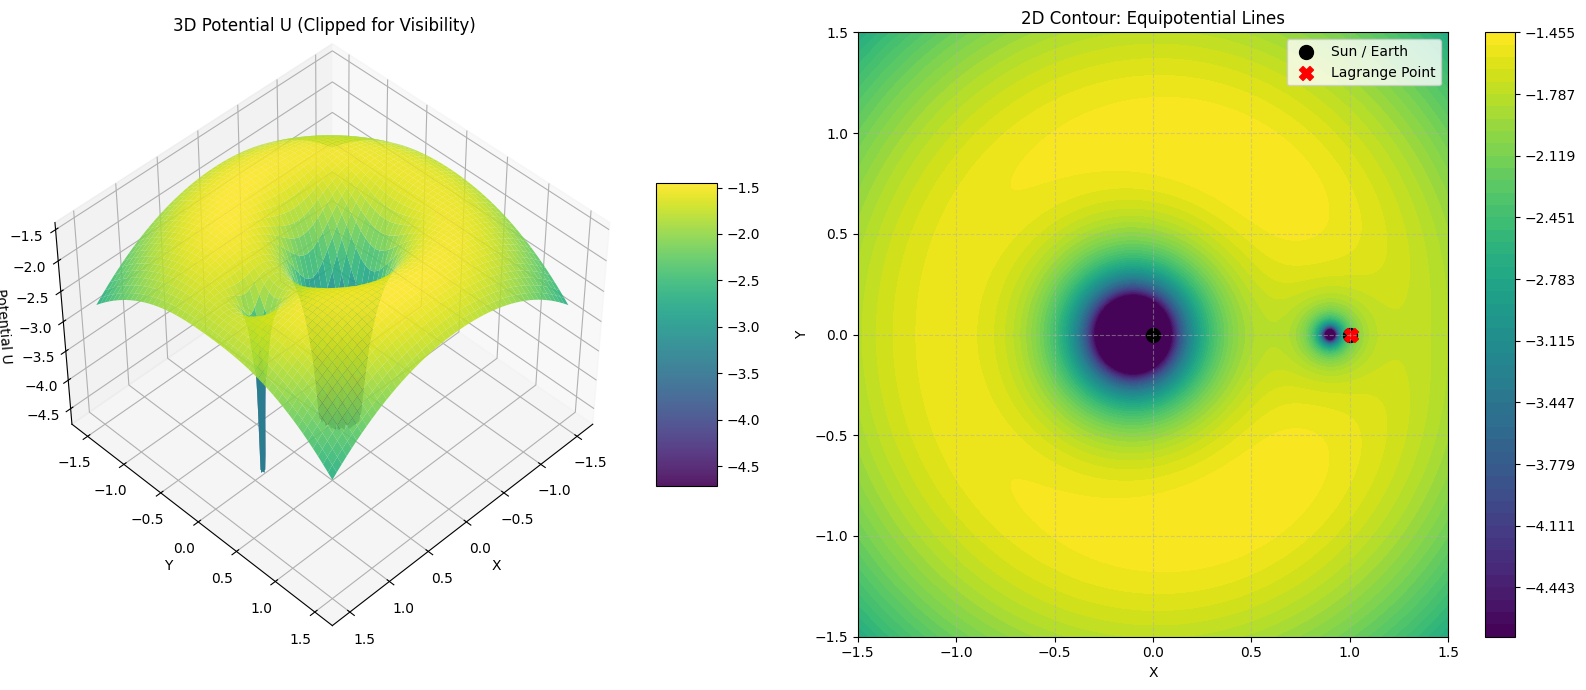

In [ ]:
# --- 1. Grid Setup ---
# Reduced to 400x400 to prevent the nested loops from taking forever.
# Domain adjusted to [-1.5, 1.5] to ensure L1, L2, L3, L4, and L5 are all in frame.
x_shift = np.linspace(-1.5, 1.5, 400)
y_shift = np.linspace(-1.5, 1.5, 400)
Y_shift, X_shift = np.meshgrid(y_shift, x_shift)
U_matrix = np.zeros(X_shift.shape)

for i in range(X_shift.shape[0]):
    for j in range(X_shift.shape[1]):
        X = np.array([X_shift[i, j], Y_shift[i, j], 0])
        U_matrix[i, j] = potential_U(X,0.1)

# --- 2. Z-Axis Clipping (CRITICAL STEP) ---
# The potential approaches infinity at the masses. We clip the extreme values 
# so the color map can distribute properly over the shallow Lagrange saddle points.
U_median = np.median(U_matrix)
# You may need to tweak the +/- bounds depending on how potential_U is defined
U_matrix_clipped = np.clip(U_matrix, U_median - 3.0, U_median + 3.0) 

# --- 3. Plotting ---
fig = plt.figure(figsize=(16, 7))

# --- Plot A: 3D Surface ---
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X_shift, Y_shift, U_matrix_clipped, cmap='viridis', alpha=0.9)
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5)

# Plotting the Lagrange point on the 3D surface (Assuming X_SE is your L2 point)
# ax1.scatter(X_SE[0], X_SE[1], potential_U(X_SE, mu_SE), color='red', s=50, label='L2')

ax1.set_title("3D Potential U (Clipped for Visibility)")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Potential U")
ax1.view_init(elev=45, azim=45) # Better viewing angle for saddles

# --- Plot B: 2D Contour (Best for Lagrange Points) ---
ax2 = fig.add_subplot(122)
# Using 50 contour levels makes the equipotential lines and saddles pop out
levels = np.linspace(np.min(U_matrix_clipped), np.max(U_matrix_clipped), 50)
contour = ax2.contourf(X_shift, Y_shift, U_matrix_clipped, levels=levels, cmap='viridis')
fig.colorbar(contour, ax=ax2)

# Plot the primary masses (Assuming standard normalized CR3BP coordinates)
ax2.scatter([-mu_SE, 1-mu_SE], [0, 0], color='black', marker='o', s=100, label='Sun / Earth')

# Plot your Lagrange points here (Replace X_SE with your specific L-point variables)
ax2.scatter([X_SE[0]], [X_SE[1]], color='red', marker='X', s=100, label='Lagrange Point')

ax2.set_title("2D Contour: Equipotential Lines")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()